In [3]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import sklearn

1.1.Data Preprocessing & Cleaning

Step One : Load Heart Disease UCI Data Set into Pandas Data Frames

In [4]:
df = pd.read_csv('Heart Disease Dataset .csv')

In [5]:
df.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure,HeartDisease
0,1,66,Male,175,86,28.1,73,0,0,0,...,0.9,1,14313,73,4,84,3,167,26.8,0
1,2,48,Male,187,81,23.2,119,0,1,3,...,1.0,1,15246,97,2,57,16,224,14.9,0
2,3,68,Male,181,71,21.7,123,1,0,0,...,1.2,1,11572,41,3,81,1,121,33.0,0
3,4,41,Male,175,70,22.9,110,0,1,1,...,1.4,0,8243,108,1,79,28,296,21.8,0
4,5,76,Female,156,75,30.8,78,0,0,4,...,1.2,0,13219,34,15,79,15,257,19.4,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            40000 non-null  int64  
 1   Age                   40000 non-null  int64  
 2   Gender                40000 non-null  str    
 3   Height_cm             40000 non-null  int64  
 4   Weight_kg             40000 non-null  int64  
 5   BMI                   40000 non-null  float64
 6   Waist_cm              40000 non-null  int64  
 7   Smoking               40000 non-null  int64  
 8   Alcohol               40000 non-null  int64  
 9   PhysicalActivity      40000 non-null  int64  
 10  DietScore             40000 non-null  int64  
 11  SleepHours            40000 non-null  float64
 12  StressLevel           40000 non-null  int64  
 13  FamilyHistory         40000 non-null  int64  
 14  Diabetes              40000 non-null  int64  
 15  Hypertension          40000 no

Step 2 : Handle missing values imputation or removal

In [7]:
df.isna().sum()

Patient_ID              0
Age                     0
Gender                  0
Height_cm               0
Weight_kg               0
BMI                     0
Waist_cm                0
Smoking                 0
Alcohol                 0
PhysicalActivity        0
DietScore               0
SleepHours              0
StressLevel             0
FamilyHistory           0
Diabetes                0
Hypertension            0
KidneyDisease           0
StrokeHistory           0
SystolicBP              0
DiastolicBP             0
RestingHR               0
RespRate                0
BodyTemp_C              0
SpO2                    0
TotalChol               0
HDL                     0
LDL                     0
Triglycerides           0
FBS                     0
HbA1c                   0
Creatinine              0
RestingECG              0
ChestPainType           0
ExerciseAngina          0
MaxHR                   0
Oldpeak                 0
STSlope                 0
DailySteps              0
HRV         

step three : Data Categorical Encoding Using Label Encode

In [8]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
df['Gender'] = LE.fit_transform(df['Gender'])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            40000 non-null  int64  
 1   Age                   40000 non-null  int64  
 2   Gender                40000 non-null  int64  
 3   Height_cm             40000 non-null  int64  
 4   Weight_kg             40000 non-null  int64  
 5   BMI                   40000 non-null  float64
 6   Waist_cm              40000 non-null  int64  
 7   Smoking               40000 non-null  int64  
 8   Alcohol               40000 non-null  int64  
 9   PhysicalActivity      40000 non-null  int64  
 10  DietScore             40000 non-null  int64  
 11  SleepHours            40000 non-null  float64
 12  StressLevel           40000 non-null  int64  
 13  FamilyHistory         40000 non-null  int64  
 14  Diabetes              40000 non-null  int64  
 15  Hypertension          40000 no

Step 4 : Standarization

Step 5 : EDA

1. Heat Map

<Axes: >

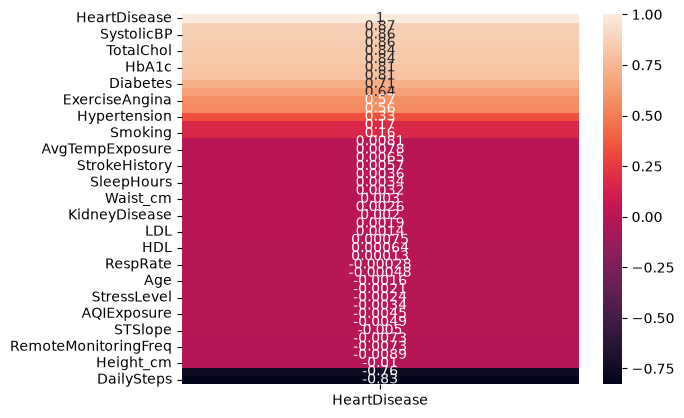

In [10]:
import seaborn as sns 
corr = df.corr()
labeled = corr[['HeartDisease']].sort_values('HeartDisease',ascending = False)
sns.heatmap(labeled,annot=True)

2. Correlation Matrix

<Axes: >

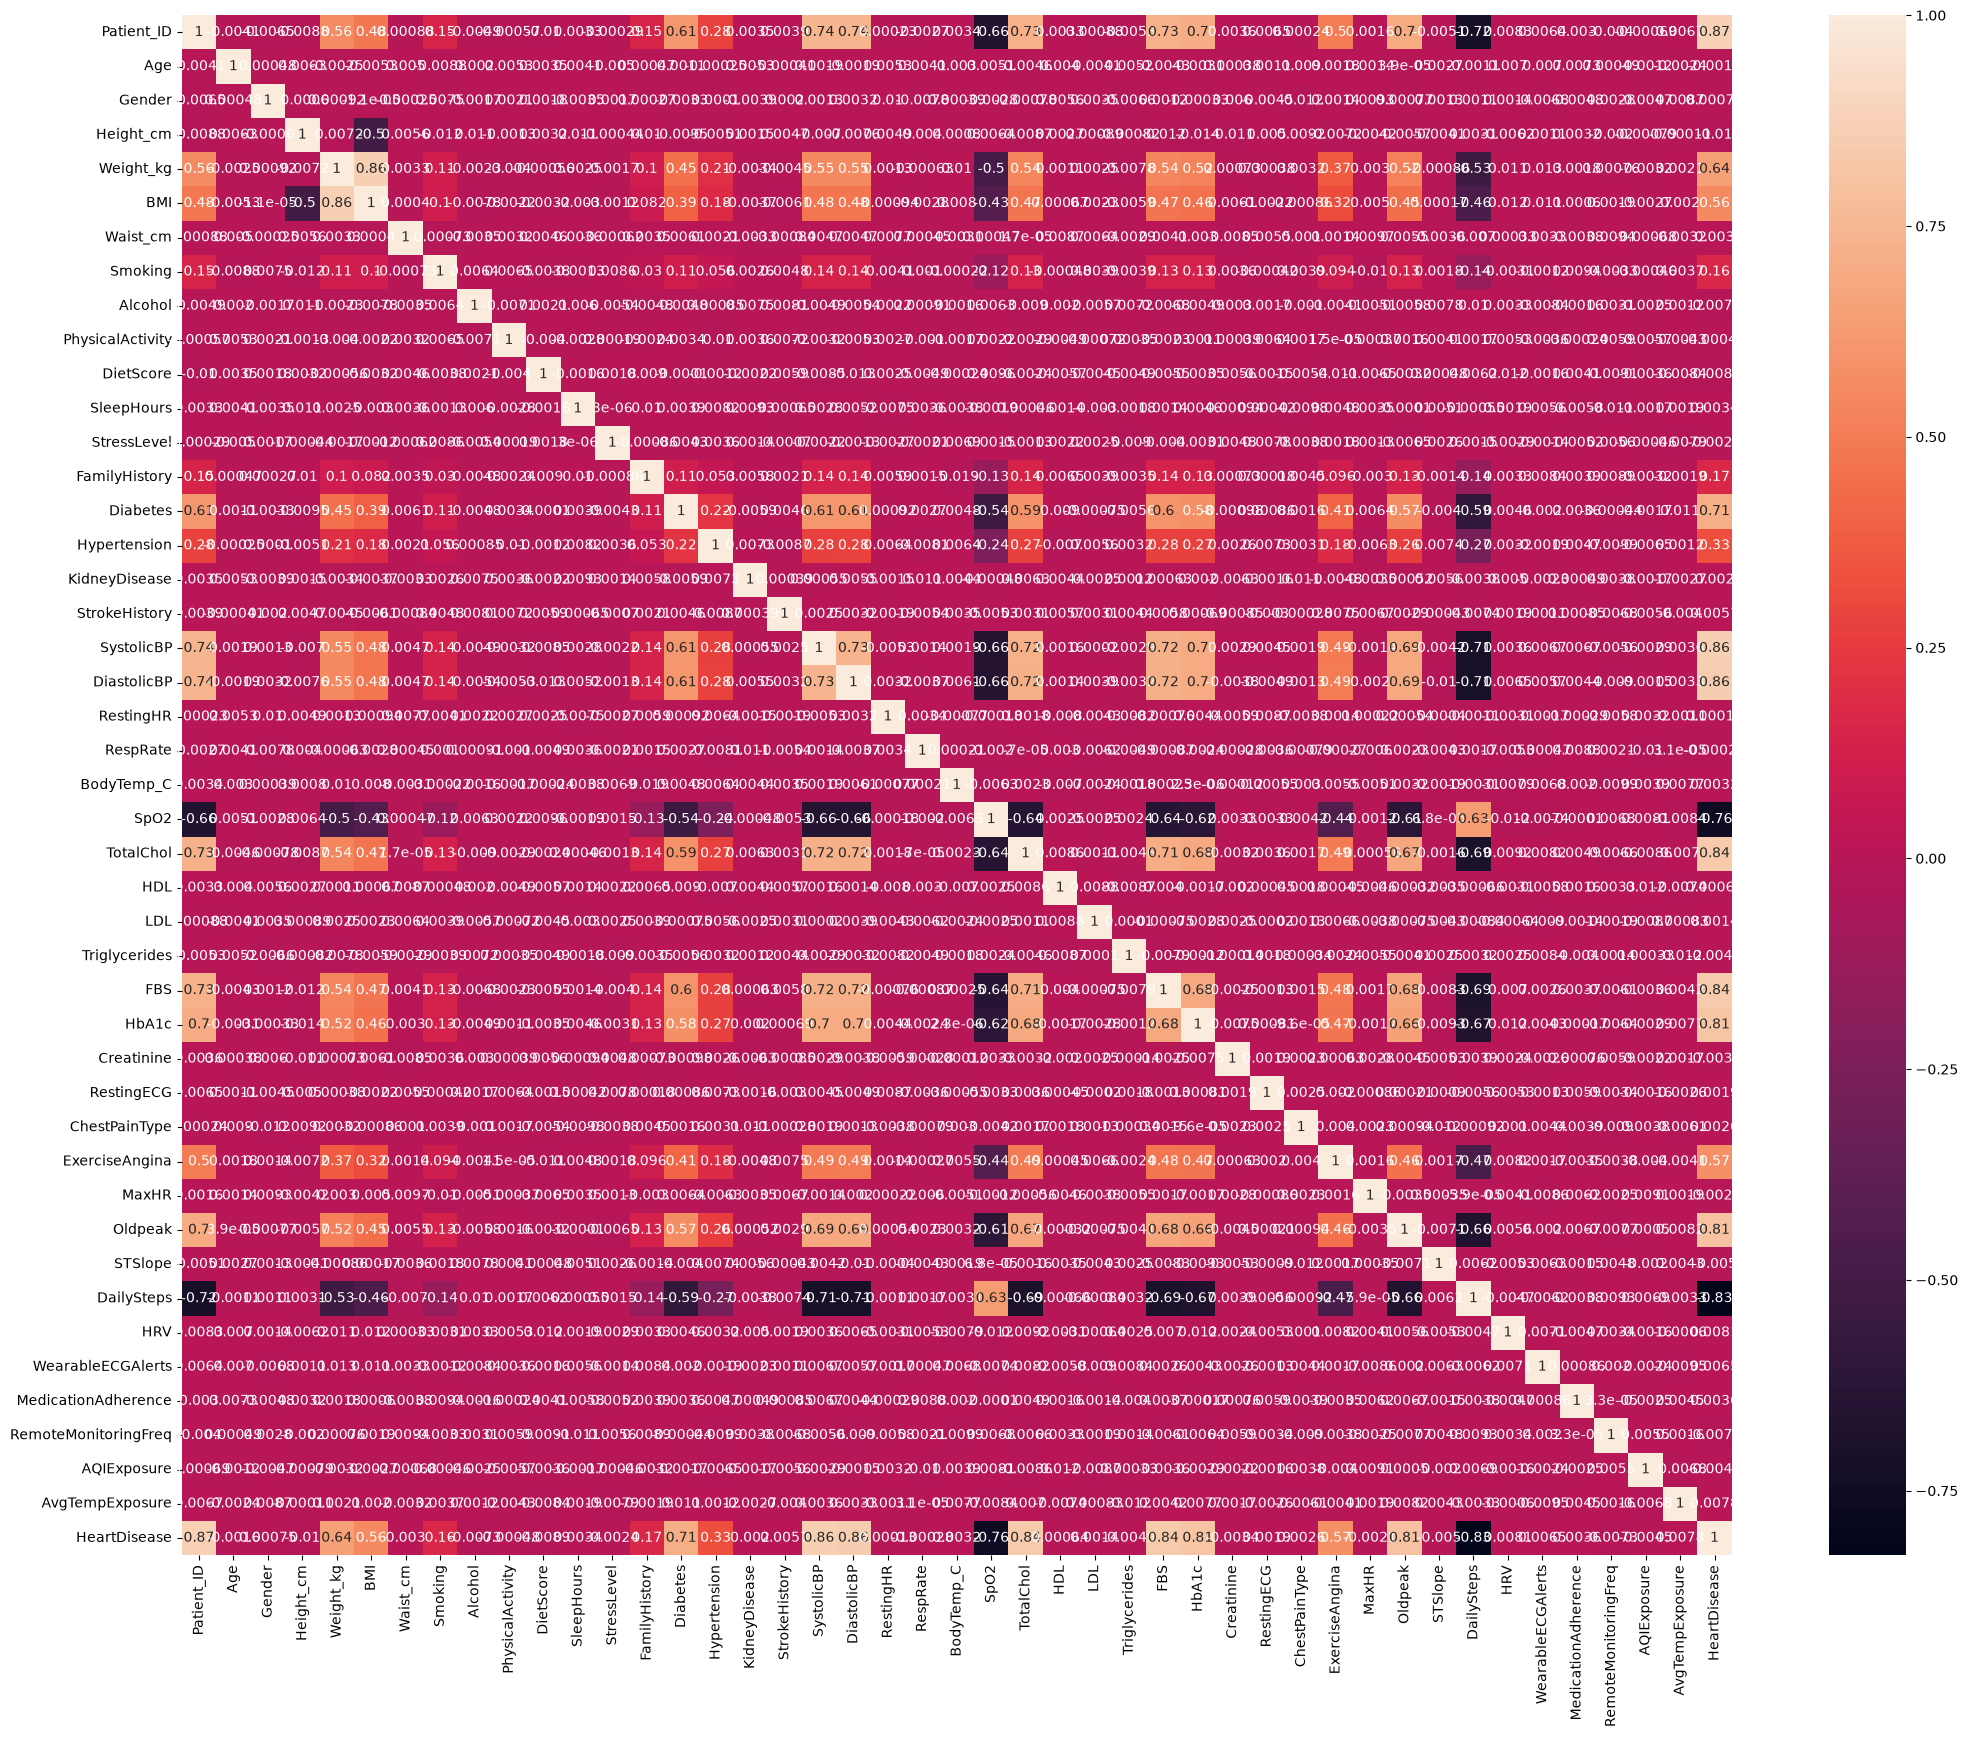

In [11]:
plt.figure(figsize=(25,20))
sns.heatmap(corr,annot=True)

PCA : Principal Component Analysis

Split Data Into Matrix X and vector y

In [12]:
X = df.drop(columns = ['HeartDisease'])
y = df['HeartDisease']

In [13]:
#Step 1 : Create covarience matrix
cov_matrix = np.cov(X,rowvar = False)
#Step 2 : create eign values and eign vectors
eignvalues,eignvectors =np.linalg.eig(cov_matrix)
#Step 3 : Sort eign values and eign vectors
sorted_indicies = np.argsort(eignvalues)[::-1]
eignvalues = eignvalues[sorted_indicies]
eignvectors = eignvectors[:,sorted_indicies]


In [14]:
eignvectors

array([[ 9.32367801e-01, -3.61494404e-01,  5.49127846e-05, ...,
         1.95149847e-07, -4.53539241e-06, -3.10932774e-06],
       [-5.29235491e-06,  3.19972837e-05,  1.18546684e-03, ...,
         6.70958328e-05, -9.45662496e-05, -4.32453731e-05],
       [-2.39281111e-07,  8.01941359e-07, -3.86747573e-05, ...,
         1.17583008e-03, -5.40307451e-04,  6.42036153e-03],
       ...,
       [-3.67738948e-06, -2.12208118e-05,  1.50230963e-04, ...,
        -4.07567456e-04, -1.09010033e-04, -2.46001412e-04],
       [-1.18512125e-05, -2.05333851e-04,  4.87882857e-03, ...,
         2.01616598e-05,  5.22052069e-06, -7.72575259e-06],
       [ 4.48648014e-06, -6.74782802e-06, -1.16786731e-03, ...,
         3.62848667e-04,  2.85660759e-04, -4.52251438e-04]],
      shape=(44, 44))

In [15]:
#Step 4: Select PCA 
n_components = 3
principal_components = eignvectors [:,:n_components]
X = np.dot(X,principal_components)
X = pd.DataFrame(X)

In [16]:
df

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure,HeartDisease
0,1,66,1,175,86,28.1,73,0,0,0,...,0.9,1,14313,73,4,84,3,167,26.8,0
1,2,48,1,187,81,23.2,119,0,1,3,...,1.0,1,15246,97,2,57,16,224,14.9,0
2,3,68,1,181,71,21.7,123,1,0,0,...,1.2,1,11572,41,3,81,1,121,33.0,0
3,4,41,1,175,70,22.9,110,0,1,1,...,1.4,0,8243,108,1,79,28,296,21.8,0
4,5,76,0,156,75,30.8,78,0,0,4,...,1.2,0,13219,34,15,79,15,257,19.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39996,87,1,186,117,33.8,112,1,0,0,...,2.0,1,5879,45,12,90,17,217,35.7,1
39996,39997,90,0,153,112,47.8,102,0,1,3,...,3.4,1,672,61,7,92,23,160,23.3,1
39997,39998,28,0,177,70,22.3,66,0,1,2,...,3.9,1,4377,57,1,61,15,109,24.5,1
39998,39999,61,1,152,98,42.4,70,1,0,1,...,4.6,0,1385,57,7,79,9,115,12.1,1


3. Feature Selection

In [17]:
selected_features = labeled[labeled['HeartDisease']>0.6]

In [18]:
selected_features = selected_features.index

In [19]:
selected_features= selected_features.to_list()

In [20]:
selected_features.remove('HeartDisease')

In [21]:
selected_features

['Patient_ID',
 'SystolicBP',
 'DiastolicBP',
 'TotalChol',
 'FBS',
 'HbA1c',
 'Oldpeak',
 'Diabetes',
 'Weight_kg']

4. Model Training 

Step 1 : Split Data Set into Trainig (80%) set and Testing(20%) Set

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size =0.2,random_state=42,shuffle=True)

1. Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score
modeLogRegl=LogisticRegression()
modeLogRegl.fit(X_train,y_train)
y_predLogReg = modeLogRegl.predict(X_train)
accuracyLogReg = accuracy_score(y_train,y_predLogReg)
#precision score
precisionLogReg = precision_score(y_train,y_predLogReg,average ='weighted')
#Recall score
recallLogReg = recall_score(y_train,y_predLogReg,average ='weighted')
#F1 score 
f1LogReg = f1_score(y_train,y_predLogReg,average ='weighted')


In [24]:
y_predLogReg = modeLogRegl.predict(X_test)
accuracyLogRegTest = accuracy_score(y_test,y_predLogReg)
#precision score
precisionLogReg = precision_score(y_test,y_predLogReg,average ='weighted')
#Recall score
recallLogReg = recall_score(y_test,y_predLogReg,average ='weighted')
#F1 score 
f1LogReg = f1_score(y_test,y_predLogReg,average ='weighted')

In [25]:
accuracyLogRegTest

1.0

2. SVM

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
#linear SVM with hard margin (large C)
model1 = SVC(kernel='linear',C=100)
#Soft Margin SVN(small c)
model2 = SVC(kernel='linear',C=0.1)
#SVM with RBF Kernel
model4 = SVC(kernel='rbf',C=1,gamma='scale' )
#SVM with polynominal Kernel (Degree = 3)
model4 = SVC(kernel='poly',degree = 3,gamma='auto',coef0=1 )
#SVM with sigmoid Kernel
model5 = SVC(kernel='sigmoid',C = 1,gamma=0.5,coef0=1 )


In [27]:
#train (fit) the model 
model5.fit(X_train,y_train)
#Make Predictions
y_predSVM = model5.predict(X_test)
#compute evaluations metrics
precisionSVM = precision_score(y_test,y_predSVM)
recallSVM =recall_score(y_test,y_predSVM)
f1SVM=f1_score(y_test,y_predSVM)
accuracySVM =accuracy_score(y_test,y_predSVM)


3.Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier
dt =DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_predDt =dt.predict(X_test)
accuracydt = accuracy_score(y_test,y_predDt)

In [29]:
accuracydt

0.99975

In [30]:
accuracySVM

0.49825

In [31]:
accuracyLogReg

1.0

Model Save

In [32]:
import joblib
model_filename  ='HeartDiagnosis.pkl'
joblib.dump(modeLogRegl,model_filename)
lodedModel =joblib.load('HeartDiagnosis.pkl')

